In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [4]:
# Loading CSV file
df = pd.read_csv(r"C:\Users\aliya\DSI_Participant\visualization\02_activities\assignments\Covid_19_cases_schools_2021_2022.csv")
print(df.head())

   _id       collected_date        reported_date  \
0    1  2021-09-13T00:00:00  2021-09-14T00:00:00   
1    2  2021-09-13T00:00:00  2021-09-14T00:00:00   
2    3  2021-09-13T00:00:00  2021-09-14T00:00:00   
3    4  2021-09-13T00:00:00  2021-09-14T00:00:00   
4    5  2021-09-13T00:00:00  2021-09-14T00:00:00   

                                        school_board school_id  \
0                Avon Maitland District School Board    507725   
1          Bruce-Grey Catholic District School Board    732800   
2  Catholic District School Board of Eastern Ontario    691127   
3  Catholic District School Board of Eastern Ontario    758787   
4  Catholic District School Board of Eastern Ontario    769312   

                                  school      municipality  \
0              Shakespeare Public School         Stratford   
1  St Teresa of Calcutta Catholic School          Brockton   
2             J L Jordan Separate School        Brockville   
3  Sacred Heart of Jesus Separate School  

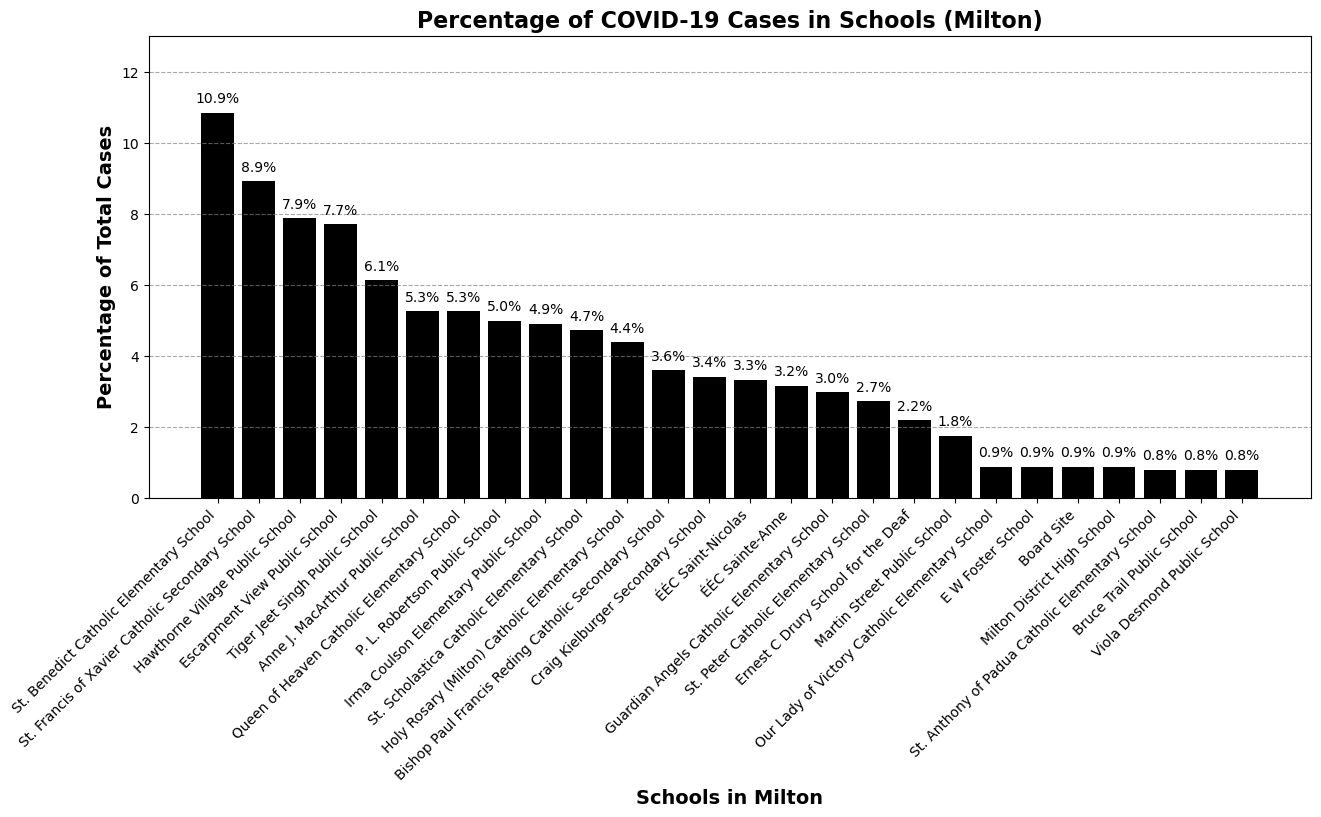

In [16]:
# Filter data for Milton
df_milton = df[df["municipality"] == "Milton"]

# Group by 'School' and sum up the total cases
cases_by_school = df_milton.groupby("school")["total_confirmed_cases"].sum().reset_index()

# Calculate total cases in Milton
total_cases_milton = cases_by_school["total_confirmed_cases"].sum()

# Calculate percentage of cases for each school
cases_by_school["Percentage"] = (cases_by_school["total_confirmed_cases"] / total_cases_milton) * 100

# Sorting by percentage for better visualization 
cases_by_school = cases_by_school.sort_values(by="Percentage", ascending=False)

# Set Y-axis limit slightly higher than max percentage for proper label positioning
y_max = cases_by_school["Percentage"].max() * 1.2  # Increase limit to make space for labels

# Create the bar chart
plt.figure(figsize=(15, 6))
bars = plt.bar(cases_by_school["school"], cases_by_school["Percentage"], color="black")

# Add data labels (percentage on top of bars)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.2, f"{height:.1f}%", 
             ha='center', va='bottom', fontsize=10, color="black")

# Labels and title with larger font size
plt.xlabel("Schools in Milton", fontsize=14, fontweight="bold")
plt.ylabel("Percentage of Total Cases", fontsize=14, fontweight="bold")
plt.title("Percentage of COVID-19 Cases in Schools (Milton)", fontsize=16, fontweight="bold")

# Improve readability of X-axis labels
plt.xticks(rotation=45, ha="right", fontsize=10)

# Set Y-axis range dynamically to make room for labels
plt.ylim(0, y_max)

# Add a grid with strong contrast
plt.grid(axis="y", linestyle="--", alpha=0.7, color="gray")

# Show the graph
plt.show()